# Day 2 — Data Cleaning + EDA

## Concepts (read first)

**EDA** = explore data with summaries and plots before modeling.  
**Cleaning** = fix duplicates, types, invalid ranges, messy categories.

**Today:** load → audit → clean → save → plot → interpret.


> **Read first:** [CONCEPTS.md](./CONCEPTS.md) in this folder.


## Setup paths and load data

Run with working directory `notebooks/day02/` (Jupyter default when you open this file). `find_project_root()` locates `dataset/` and `outputs/`.


In [1]:
# pathlib.Path — cross-platform file/folder paths
from pathlib import Path

# Plotting and data libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Walk up from notebooks/dayXX/ to project root
def find_project_root() -> Path:
    """Locate repo root (dataset/ + requirements.txt) from notebooks/dayXX/."""
    p = Path.cwd().resolve()
    for _ in range(6):
        if (p / "dataset").is_dir() and (p / "requirements.txt").exists():
            return p
        p = p.parent
    raise FileNotFoundError("Project root not found. cwd should be notebooks/dayXX/.")

PROJECT_ROOT = find_project_root()
# Folder containing CSV files
DATA_DIR = PROJECT_ROOT / "dataset"
# Where we write cleaned CSV and figures
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
# Create outputs/figures if it does not exist; exist_ok avoids errors
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Seaborn default style; whitegrid adds light grid lines
sns.set_theme(style="whitegrid", context="notebook")
# Default figure size for all plots in this session (width, height in inches)
plt.rcParams["figure.figsize"] = (10, 5)

# Path to the raw student dataset
RAW_PATH = DATA_DIR / "AI_Career_Guidance_Dataset.csv"
# Read CSV into a DataFrame (rows = students, columns = features + Career)
raw_df = pd.read_csv(RAW_PATH)
# Display (rows, columns) — e.g. (3000, 24)
raw_df.shape


(3000, 24)

## 1. Cleaning audit (before changing anything)

Document data quality **before** any edits (for report and viva).


In [2]:
def cleaning_audit(df: pd.DataFrame) -> pd.DataFrame:
    """Build a one-row-per-check summary table."""
    # Skill columns expected on scale 1–5
    rating_cols = [
        "Python", "Java", "SQL", "Web_Development", "Cybersecurity", "Cloud_Computing",
        "Mathematics", "Statistics", "Data_Analysis", "Problem_Solving", "Communication",
        "Creativity", "Leadership", "Teamwork", "Logical_Reasoning", "Presentation",
    ]
    # Count-type experience fields (must be >= 0)
    exp_cols = ["Internships", "Projects", "Certifications"]

    checks = []
    checks.append(("rows", len(df), "—"))  # number of students
    checks.append(("columns", len(df.columns), "—"))  # number of variables
    # Total missing values across entire table
    checks.append(("missing_cells", int(df.isnull().sum().sum()), "—"))
    # Rows identical on every column
    checks.append(("duplicate_rows", int(df.duplicated().sum()), "—"))
    # Same Student_ID appearing more than once
    checks.append(("duplicate_Student_ID", int(df["Student_ID"].duplicated().sum()), "—"))
    # CGPA should be on 0–10 scale in this project
    checks.append(("CGPA_out_of_0_10", int(((df["CGPA"] < 0) | (df["CGPA"] > 10)).sum()), "0–10"))
    # Any skill rating below 1 or above 5?
    bad_rating = (df[rating_cols] < 1).any(axis=1) | (df[rating_cols] > 5).any(axis=1)
    checks.append(("skill_rating_outside_1_5", int(bad_rating.sum()), "1–5"))
    # Negative internship/project/cert counts are invalid
    bad_exp = (df[exp_cols] < 0).any(axis=1)
    checks.append(("negative_experience_counts", int(bad_exp.sum()), ">= 0"))

    return pd.DataFrame(checks, columns=["check", "count", "expected"])


# Run audit on raw data (no changes yet)
audit_before = cleaning_audit(raw_df)
audit_before


,check,count,expected
0,rows,3000,—
1,columns,24,—
2,missing_cells,0,—
3,duplicate_rows,0,—
4,duplicate_Student_ID,0,—
5,CGPA_out_of_0_10,0,0–10
6,skill_rating_outside_1_5,0,1–5
7,negative_experience_counts,0,>= 0


## 2. Apply cleaning pipeline

Same logic you will move to `src/preprocessing.py` on Day 3.


In [3]:
# Reusable column groups for cleaning and later ML
RATING_COLS = [
    "Python", "Java", "SQL", "Web_Development", "Cybersecurity", "Cloud_Computing",
    "Mathematics", "Statistics", "Data_Analysis", "Problem_Solving", "Communication",
    "Creativity", "Leadership", "Teamwork", "Logical_Reasoning", "Presentation",
]
EXP_COLS = ["Internships", "Projects", "Certifications"]
CAT_COLS = ["Interest_Area", "Career"]  # categorical text fields


def clean_career_dataset(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    # Copy so we do not modify the original DataFrame
    out = df.copy()
    log = []  # list of (action_name, rows_removed)

    n0 = len(out)
    out = out.drop_duplicates()  # remove 100% duplicate rows
    log.append(("drop_duplicate_rows", n0 - len(out)))

    n0 = len(out)
    # If duplicate Student_ID, keep first occurrence only
    out = out.drop_duplicates(subset=["Student_ID"], keep="first")
    log.append(("drop_duplicate_Student_ID", n0 - len(out)))

    for col in CAT_COLS:
        # Strip leading/trailing spaces so "Web" and " Web " encode the same
        out[col] = out[col].astype(str).str.strip()

    # Convert to numeric; invalid text becomes NaN (errors="coerce")
    out["CGPA"] = pd.to_numeric(out["CGPA"], errors="coerce")
    for col in RATING_COLS + EXP_COLS + ["Age"]:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    # Boolean mask: True = row passes all range rules
    valid = (
        out["CGPA"].between(0, 10)
        & out[RATING_COLS].ge(1).all(axis=1)
        & out[RATING_COLS].le(5).all(axis=1)
        & out[EXP_COLS].ge(0).all(axis=1)
        & out["Age"].between(15, 40)
    )
    n0 = len(out)
    out = out.loc[valid].reset_index(drop=True)  # keep valid rows only
    log.append(("drop_invalid_ranges", n0 - len(out)))

    n0 = len(out)
    # Drop rows that still have NaN in critical columns
    out = out.dropna(subset=["Career", "Interest_Area", "CGPA"] + RATING_COLS)
    log.append(("drop_rows_with_NaN_after_coerce", n0 - len(out)))

    change_log = pd.DataFrame(log, columns=["action", "rows_removed"])
    return out, change_log


clean_df, change_log = clean_career_dataset(raw_df)
change_log


,action,rows_removed
0,drop_duplicate_rows,0
1,drop_duplicate_Student_ID,0
2,drop_invalid_ranges,0
3,drop_rows_with_NaN_after_coerce,0


In [4]:
# Re-run quality checks after cleaning
audit_after = cleaning_audit(clean_df)
print(f"Raw rows: {len(raw_df):,} → Clean rows: {len(clean_df):,}")
# Stack before/after audits for report tables (shown as cell output)
audit_comparison = pd.concat(
    [audit_before.assign(stage="before"), audit_after.assign(stage="after")],
    ignore_index=True,
)
audit_comparison


Raw rows: 3,000 → Clean rows: 3,000


,check,count,expected,stage
0,rows,3000,—,before
1,columns,24,—,before
2,missing_cells,0,—,before
3,duplicate_rows,0,—,before
4,duplicate_Student_ID,0,—,before
5,CGPA_out_of_0_10,0,0–10,before
6,skill_rating_outside_1_5,0,1–5,before
7,negative_experience_counts,0,>= 0,before
8,rows,3000,—,after
9,columns,24,—,after


In [5]:
# Save cleaned data for Day 3+ (training should use the same table as EDA)
CLEAN_PATH = OUTPUT_DIR / "AI_Career_Guidance_Dataset_cleaned.csv"
clean_df.to_csv(CLEAN_PATH, index=False)
CLEAN_PATH


PosixPath('/Users/sarojsasamal/Documents/Professional/CareerGuidanceMLEngine/outputs/AI_Career_Guidance_Dataset_cleaned.csv')

---

## 3. EDA — charts

For each chart, note:
1. What am I looking at?  
2. What pattern do I see?  
3. Does it prove causation? (No — association only.)  
4. What could explain the pattern?

All plots use `clean_df`.


### Chart 1 — Career distribution (target class balance)

| Axis | Meaning |
|------|---------|
| **Y-axis** | Career name (target label we will predict in ML) |
| **X-axis** | **Count** — number of students with that career in the dataset |

**Read:** Longer bar = more training examples. Imbalance affects accuracy vs per-class F1.


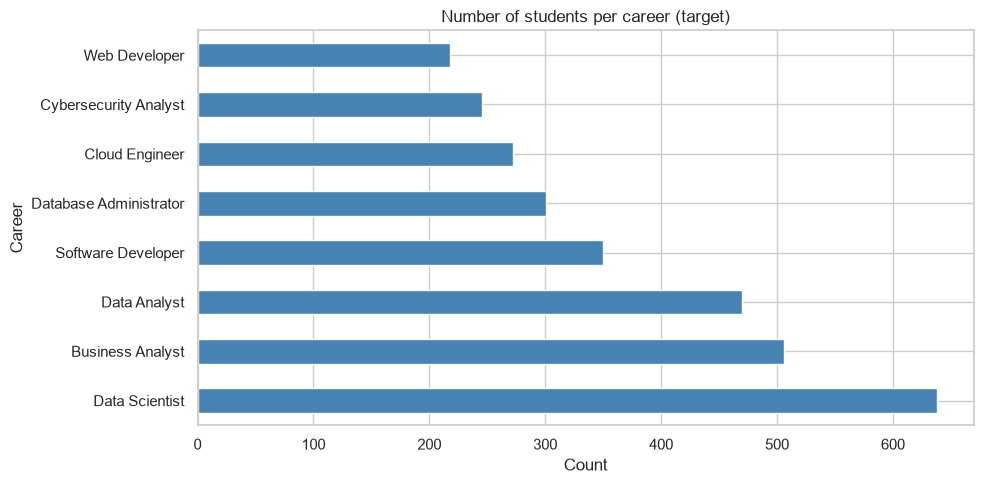

Career
Data Scientist            638
Business Analyst          506
Data Analyst              470
Software Developer        350
Database Administrator    301
Cloud Engineer            272
Cybersecurity Analyst     245
Web Developer             218
Name: count, dtype: int64

In [6]:
# value_counts: how many rows per unique Career label
career_counts = clean_df["Career"].value_counts()
# barh = horizontal bars; steelblue = bar color
ax = career_counts.plot(kind="barh", color="steelblue", edgecolor="white")
ax.set_title("Number of students per career (target)")
ax.set_xlabel("Count")  # X = number of students
# Y-axis labels are career names (automatic from index)
plt.tight_layout()  # reduce label clipping
plt.savefig(FIGURES_DIR / "01_career_distribution.png", dpi=150)
plt.show()

career_counts


### Chart 2 — CGPA distribution

| Axis | Meaning |
|------|---------|
| **X-axis** | CGPA value (0–10 academic scale) |
| **Y-axis** | **Count** (histogram) or **density** (KDE curve) — how many students fall in each CGPA bin |

**Read:** Shape shows whether CGPA is symmetric, skewed, or multi-peaked.


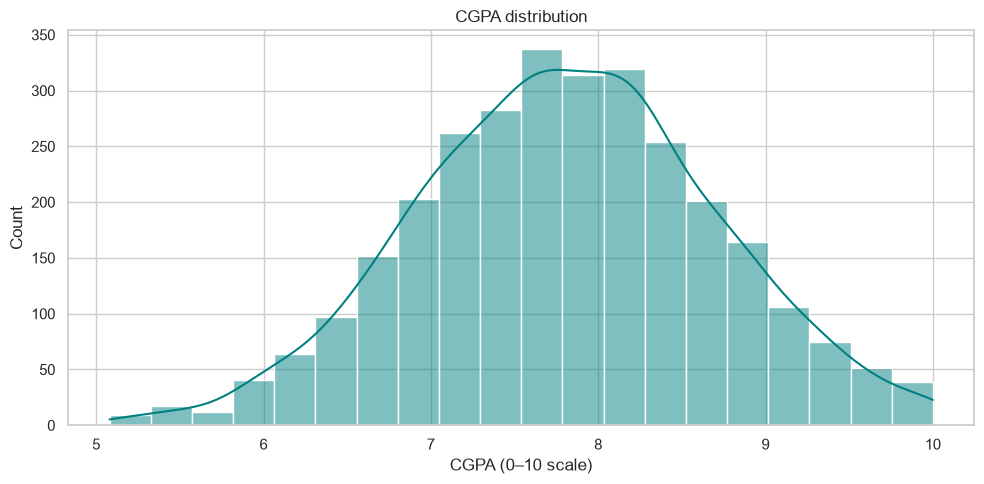

count    3000.00000
mean        7.80444
std         0.89328
min         5.08000
25%         7.20000
50%         7.80000
75%         8.40000
max        10.00000
Name: CGPA, dtype: float64

In [7]:
# bins=20 splits CGPA into 20 intervals; kde=True overlays smooth density curve
ax = sns.histplot(clean_df["CGPA"], bins=20, kde=True, color="teal")
ax.set_title("CGPA distribution")
ax.set_xlabel("CGPA (0–10 scale)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_cgpa_histogram.png", dpi=150)
plt.show()
# Numeric summary: mean, std, min, quartiles, max
clean_df["CGPA"].describe()


### Chart 3 — Technical skill ratings (boxplots)

| Axis | Meaning |
|------|---------|
| **X-axis** | Skill name (Python, Java, SQL, …) |
| **Y-axis** | **Rating** from 1 (low) to 5 (high) |

**Box:** median (line), IQR (box), whiskers = spread. **Read:** Compare typical level per technical skill.


/var/folders/l7/94_mwjx10cd64_2df844f18r0000gn/T/ipykernel_36445/1906236375.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=tech_long, x="skill", y="rating", palette="muted")
/var/folders/l7/94_mwjx10cd64_2df844f18r0000gn/T/ipykernel_36445/1906236375.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


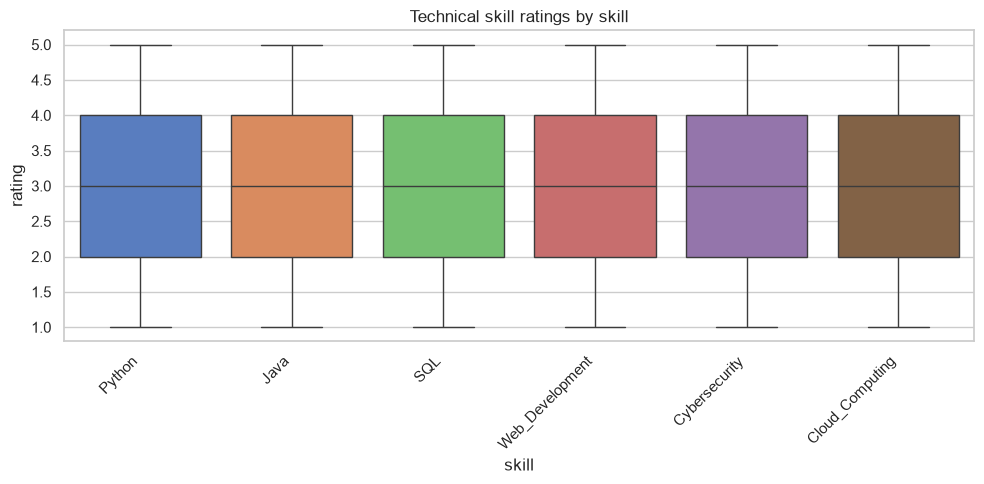

In [8]:
# Six technical skill columns from the dataset
tech_skills = ["Python", "Java", "SQL", "Web_Development", "Cybersecurity", "Cloud_Computing"]
# melt: one row per student-skill with columns skill, rating
tech_long = clean_df[tech_skills].melt(var_name="skill", value_name="rating")
ax = sns.boxplot(data=tech_long, x="skill", y="rating", palette="muted")
ax.set_title("Technical skill ratings by skill")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_technical_skill_boxplots.png", dpi=150)
plt.show()


### Chart 4 — Interest area distribution

| Axis | Meaning |
|------|---------|
| **X-axis** | Interest area category (Business, Cloud, Data, …) |
| **Y-axis** | **Count** — students who selected that interest |

**Read:** Feature distribution (not the target). Imbalance here affects how interest enters the model after encoding.


/var/folders/l7/94_mwjx10cd64_2df844f18r0000gn/T/ipykernel_36445/590531564.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=interest_counts.index, y=interest_counts.values, palette="viridis")


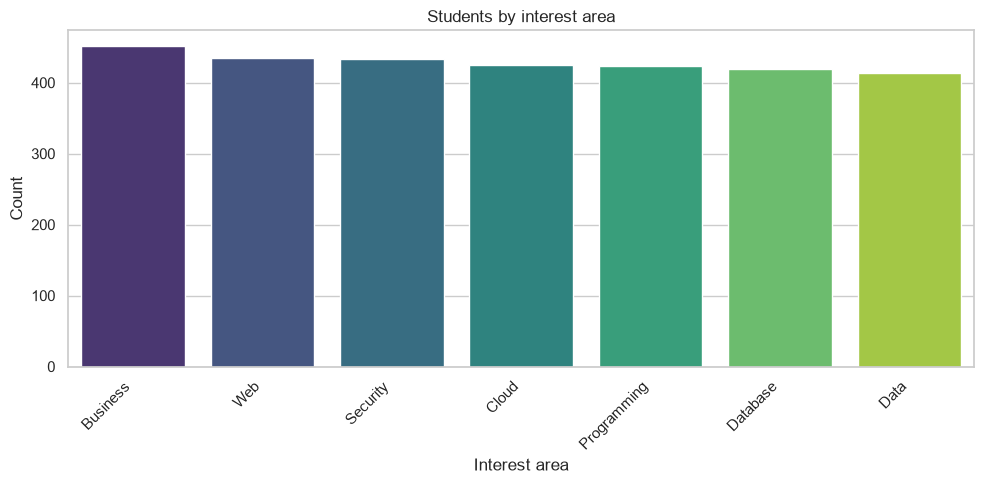

In [9]:
interest_counts = clean_df["Interest_Area"].value_counts()
# x = category names, y = counts
ax = sns.barplot(x=interest_counts.index, y=interest_counts.values, palette="viridis")
ax.set_title("Students by interest area")
ax.set_xlabel("Interest area")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_interest_distribution.png", dpi=150)
plt.show()


### Chart 5 — Experience counts

| Axis | Meaning |
|------|---------|
| **X-axis** | **Count** — number of internships / projects / certifications |
| **Y-axis** | **Frequency** — how many student-records fall in each bin |
| **Colors (hue)** | Experience type: Internships, Projects, Certifications |

**Read:** Side-by-side histograms (`multiple="dodge"`) compare experience types.


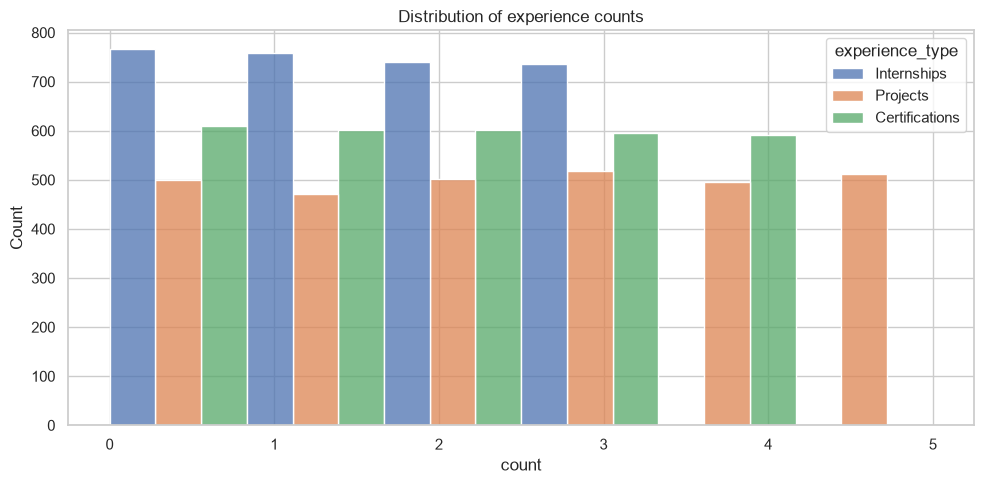

,Internships,Projects,Certifications
count,3000.000000,3000.000000,3000.000000
mean,1.481333,2.525667,1.986667
std,1.118363,1.708112,1.414622
min,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000
50%,1.000000,3.000000,2.000000
75%,2.000000,4.000000,3.000000
max,3.000000,5.000000,4.000000


In [10]:
# Melt three experience columns into long format for grouped histogram
exp_long = clean_df[EXP_COLS].melt(var_name="experience_type", value_name="count")
ax = sns.histplot(data=exp_long, x="count", hue="experience_type", bins=6, multiple="dodge")
ax.set_title("Distribution of experience counts")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_experience_distributions.png", dpi=150)
plt.show()
clean_df[EXP_COLS].describe()


### Chart 6 — Correlation heatmap (numeric features)

| Axis | Meaning |
|------|---------|
| **X-axis** | Feature name (numeric column) |
| **Y-axis** | Feature name (numeric column) |
| **Color** | Pearson **correlation** between −1 and +1 (red ≈ positive, blue ≈ negative) |

Career and Interest_Area are excluded (categorical). Student_ID excluded (not a meaningful feature).


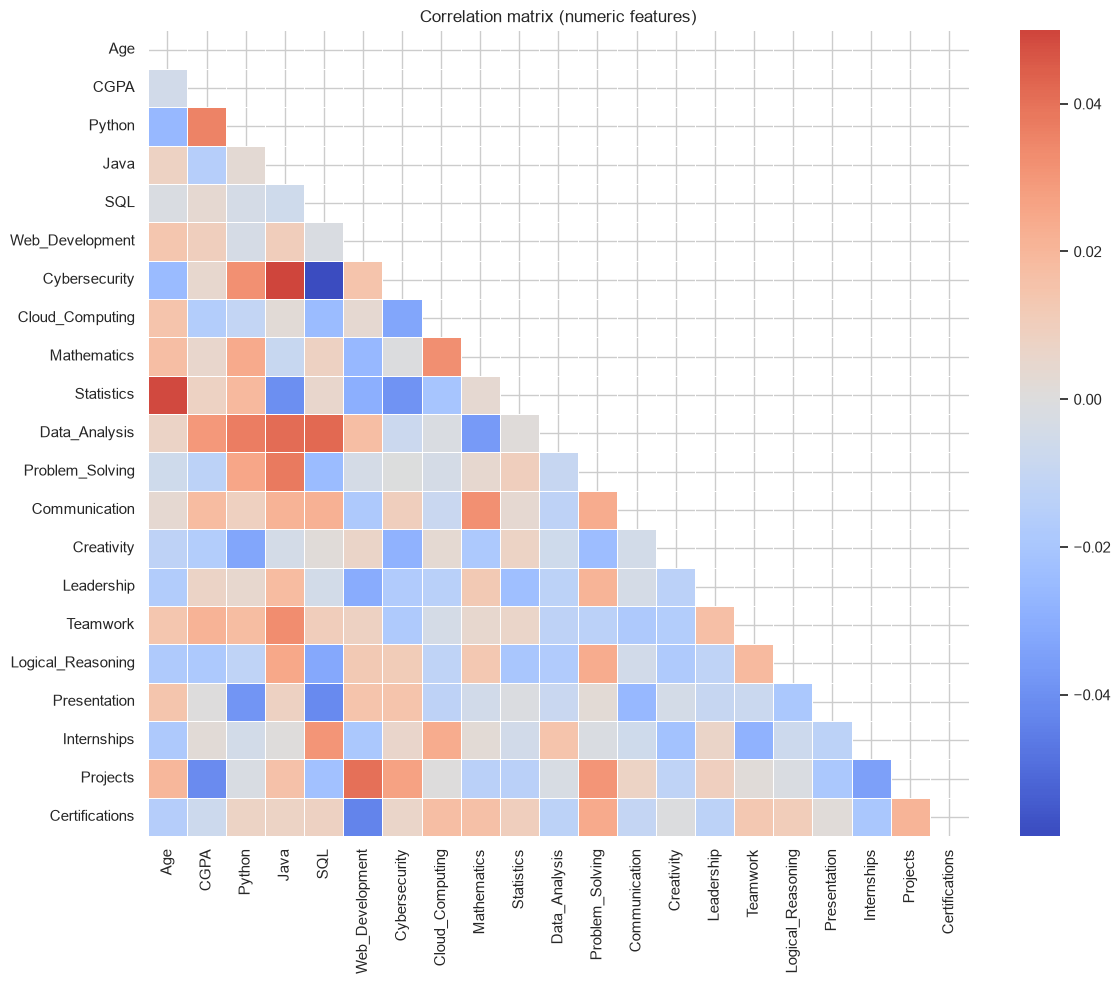

In [11]:
# Only numeric columns for correlation matrix
num_for_corr = clean_df.drop(columns=["Student_ID", "Career", "Interest_Area"])
# corr(): each cell = linear correlation between two columns
corr = num_for_corr.corr()
# Upper triangle mask — matrix is symmetric, show half only
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_correlation_heatmap.png", dpi=150)
plt.show()


### Chart 7 — Career vs interest (crosstab heatmap)

| Axis | Meaning |
|------|---------|
| **Y-axis** | Interest area (student’s stated interest) |
| **X-axis** | Career (label in dataset) |
| **Color** | **Count** of students with that (interest, career) pair |

**Read:** Dark cells = strong association in data, not proof that interest alone causes that career.


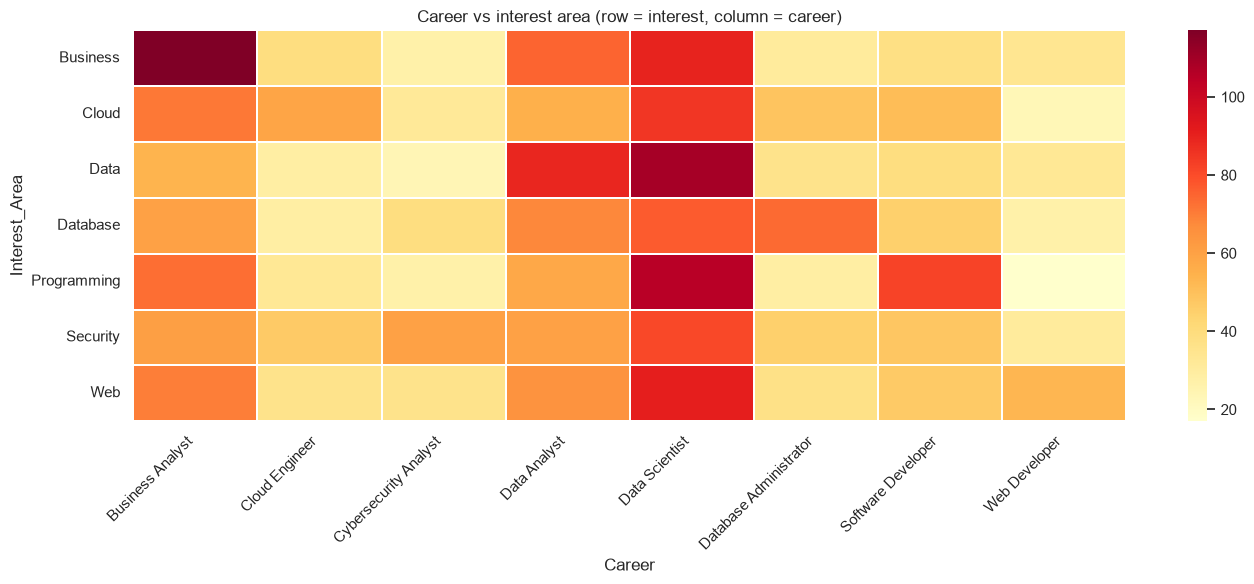

In [12]:
# Crosstab: rows=Interest_Area, columns=Career, values=student counts
ct = pd.crosstab(clean_df["Interest_Area"], clean_df["Career"])
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(ct, cmap="YlOrRd", ax=ax, linewidths=0.3)
ax.set_title("Career vs interest area (row = interest, column = career)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_career_vs_interest.png", dpi=150)
plt.show()


## 4. Optional table — mean CGPA and skills by career

No chart: grouped means for your report (which careers average higher CGPA in this sample).


In [13]:
# groupby Career: average CGPA and first three rating columns per career
summary_by_career = (
    clean_df.groupby("Career")[["CGPA"] + RATING_COLS[:3]]
    .mean()
    .round(2)
    .sort_values("CGPA", ascending=False)
)
summary_by_career.head(10)


,CGPA,Python,Java,SQL
Career,,,,
Data Analyst,7.93,2.74,3.04,3.24
Software Developer,7.85,3.21,3.28,2.89
Business Analyst,7.83,2.77,3.00,2.85
Data Scientist,7.80,3.07,2.97,2.86
Cybersecurity Analyst,7.77,2.96,3.04,2.94
Database Administrator,7.76,2.70,3.03,3.28
Cloud Engineer,7.70,2.98,3.05,2.92
Web Developer,7.65,3.25,3.20,3.04


## Day 2 — Daily learning log

| Question | Your notes |
|----------|------------|
| What I learned | |
| What I implemented | |
| What surprised me | |
| Problems & fixes | |
| Can I explain without code? | Yes / No |

**Checkpoint:** If class balance is uneven, how might accuracy vs F1 differ on Day 5?
